# Consistency benchmarks

Quantifying consistency of implemented protocols in terms of dirty reads, synchrony violations, latency and throughput.

Benchmark used: YCSB A, B, high_contention

MONSTER protocol params:

- round_time
- read_retries
- read_offset

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Synchrony tests & read retries

Test the effect of read retries and synchrony in MONSTER and ABE.


In [130]:
read_retries = [0, 1, 10, 100, 1000]

# 9 processes (low contention)
print("9 processes, ycab a low contention")

p9_abe_tput = [ 374001.05, 480625, 517672, 587166, 620122]
p9_abe_dr = [ 0.567, 0.061, 0.032, 0.010, 9 / 1005241]
# 0% sync
p9_monster10r_tput = [ 231000, 323000, 325026, 325705, 325705] 
p9_monster10r_dr = [ 0.148, 11 / 1005092, 2 / 1005678,  3 / 1005678, 3 / 1005678]
# 
print(f'1200r sync rate: {1 - 791328/1005007} ')
p9_monster1200r_tput = [215009, 272127, 272980, 272669, 272669]
p9_monster1200r_dr = [885 / 1005678, 6 / 1003285, 1 / 1004897, 1 / 1003285, 1 / 1003285]
#
print(f'1300r sync rate: {1 - 249138 / 1005193} ')
p9_monster1300r_tput = [197428, 273964, 273754, 273752, 273752 ]
p9_monster1300r_dr = [0.162, 5 / 1005092, 1 / 1005007, 1 / 1005193, 1 / 1005193 ]
#
print(f'1400r sync rate: {1 - 211598 / 1005193} ')
p9_monster1400r_tput = [184278, 267237, 269381, 269792, 269792 ]
p9_monster1400r_dr = [ 2178 / 1005193, 7 / 1005193, 1 / 1003285, 1 / 1003285 ]
#
print(f'1500r sync rate: {1 - 119602 / 1005193} ')
p9_monster1500r_tput = [182000, 259687, 259554, 259910, 259910 ]
p9_monster1500r_dr = [ 2353 / 1004897, 3 / 1003285, 2 / 1005678, 1 / 1005678, 1 / 1005678 ]
#
print(f'1700r sync rate: {1 - 10325 / 1005193} ')
p9_monster1700r_tput = [ 197909, 233959, 233451, 233743, 233743 ]
p9_monster1700r_dr = [ 536 / 1005193, 4 / 1005193,  1 / 1005193, 1 / 1005193, 1 / 1005193 ]

# 64 processes (medium contention)
print("64 processes  ycsb a (medium contention)")

p64_abe_tput = [ 176353, 196211, 200966, 239067, 232605]
p64_abe_dr = [ 35973 / 1004710, 19278 / 1004710, 5068 / 1005399, 152 / 1004813, 1 / 1004813] 
# 0% sync
p64_monster10r_tput = [79290, 103688, 104174, 104422, 104422] 
p64_monster10r_dr = [ 5241 / 1004813, 120 / 1004506, 4 / 1005511, 4 / 1005511]
# 
print(f'1300r sync rate: {1 - 898928 / 1005193} ')
p64_monster1300r_tput = [ 115000, 18200, 18600, 189000, 189000 ]
p64_monster1300r_dr = [8481 / 1004710, 129 / 1004637, 1 / 1004967, 1 / 1004967, 1 / 1004967, 1 / 1004967 ]
# 
print(f'1500r sync rate: {1 - 642958 / 1005193} ')
p64_monster1500r_tput = [ 111000, 180000, 185000, 185000, 185000 ]
p64_monster1500r_dr = [8705 / 1006615, 104 / 1004710, 1 / 1005283, 1 / 1005283, 1 / 1005283 ]
# 
print(f'1700r sync rate: {1 - 392891 / 1005193} ')
p64_monster1700r_tput = [118000, 175000, 181000, 181000, 181000 ]
p64_monster1700r_dr = [ 9625 / 1004967, 91 / 1004813, 1 / 1004813, 1 / 1004813, 1 / 1004813 ]
# 
print(f'2000r sync rate: {1 - 205225 / 1005193} ')
p64_monster2000r_tput = [118000, 173000, 174000, 174000, 174000 ]
p64_monster2000r_dr = [ 5769 / 1004710, 2 / 1004637, 1 / 1004967, 1 / 1004967, 1 / 1004967 ]
# 
print(f'3100r sync rate: {1 - 9183 / 1005193} ')
p64_monster3100r_tput = [88000, 145000, 145000, 145000, 145000 ]
p64_monster3100r_dr = [ 7648 / 1005551, 6 / 1004967, 1 / 1004967, 1 / 1004967, 1 / 1004967 ]


# 9 processes, ycsb a single key (extreme contention)
print("9 processes, ycsb a single key (medium contention)")

p9sk_abe_tput = [ 126506, 117395, 82000, 44120, 7718 ]
p9sk_abe_dr = [ 417142 / 1005610, 316983 / 1005627, 59332 / 1005520, 24381 / 1006520, 25564 / 1005520 ] 
# 0% sync
p9sk_monster10r_tput = [85000, 94500, 112000, 111000, 111000  ] 
p9sk_monster10r_dr = [ 106407 / 1005670, 7182 / 1005244, 1 / 1005627, 1 / 1005627, 1 / 1005627 ]
# 
print(f'1200r sync rate: {1 - 755871 / 1005193} ')
p9sk_monster1200r_tput = [ 80000, 101000, 122750, 121625, 120625  ]
p9sk_monster1200r_dr = [66927 / 1004063, 2180 / 1005610, 1 / 1006520, 1 / 1006520, 1 / 1006520 ]
# 
print(f'1500r sync rate: {1 - 252401 / 1005193} ')
p9sk_monster1500r_tput = [ 80375, 108740, 127375,  127000, 127000  ]
p9sk_monster1500r_dr = [ 88696 / 1004063, 2019 / 1004063, 2 / 1004063, 1 / 1004063, 1 / 1004063]
# 
print(f'2500r sync rate: {1 - 6951 / 1005193} ')
p9sk_monster2500r_tput = [ 71250, 110875, 113875, 113875, 113875 ]
p9sk_monster2500r_dr = [ 49424 / 1005610, 74 / 1005610, 2 / 1005670, 2 / 1005670, 2 / 1005670]

9 processes, ycab a low contention
1200r sync rate: 0.21261443950141645 
1300r sync rate: 0.7521490897767891 
1400r sync rate: 0.7894951516773396 
1500r sync rate: 0.8810158845117306 
1700r sync rate: 0.9897283407266068 
64 processes  ycsb a (medium contention)
1300r sync rate: 0.1057160167251463 
1500r sync rate: 0.36036363166078555 
1700r sync rate: 0.6091387425101449 
2000r sync rate: 0.7958352276627474 
3100r sync rate: 0.9908644409581046 
9 processes, ycsb a single key (medium contention)
1200r sync rate: 0.24803395964755026 
1500r sync rate: 0.7489029469962485 
2500r sync rate: 0.9930849100620478 


In [165]:
(64+50+44+40+39+38+37+37) / 8

43.625

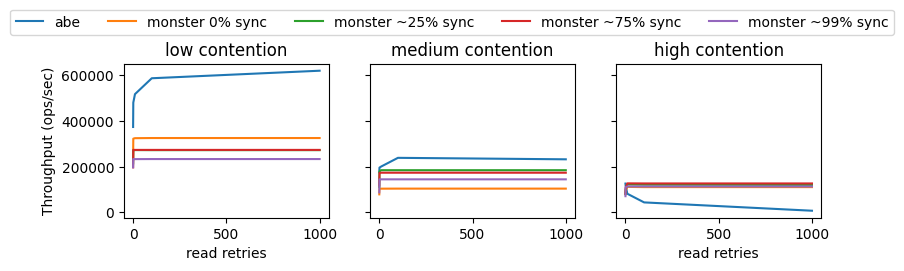

In [148]:
fig, axs = plt.subplots(1,3, sharey="all", figsize=(9, 2))

ax = axs[0]
ax.set_title("low contention")
ax.plot(read_retries, p9_abe_tput, label="abe")
ax.plot(read_retries, p9_monster10r_tput, label="monster 0% sync")
ax.plot(read_retries, p9_monster1200r_tput, label="monster 21% sync")
ax.plot(read_retries, p9_monster1300r_tput, label="monster 75% sync")
ax.plot(read_retries, p9_monster1700r_tput, label="monster 98% sync")

ax.set_ylabel("Throughput (ops/sec)")
ax.set_xlabel("read retries")

# ax.legend(loc="center", bbox_to_anchor=(2,1.6), ncols=5)
# ax.set_xscale("log")
# # ax.set_yscale("log")

ax = axs[1]
ax.set_title("medium contention")
ax.plot(read_retries, p64_abe_tput, label="abe")
ax.plot(read_retries, p64_monster10r_tput, label="monster 0% sync")
ax.plot(read_retries, p64_monster1500r_tput, label="monster 31% sync")
ax.plot(read_retries, p64_monster2000r_tput, label="monster 79% sync")
ax.plot(read_retries, p64_monster3100r_tput, label="monster 99% sync")
# ax.plot(read_retries, p64_monster1700r_tput, label="monster 98% sync")
# ax.legend(loc="center", bbox_to_anchor=(0.6,1.4), ncols=5)
# ax.set_xscale("log")
# ax.set_xlabel("read retries")


ax = axs[2]
ax.set_title("high contention")
ax.plot(read_retries, p9sk_abe_tput, label="abe")
ax.plot(read_retries, p9sk_monster10r_tput, label="monster 0% sync")
ax.plot(read_retries, p9sk_monster1200r_tput, label="monster ~25% sync")
ax.plot(read_retries, p9sk_monster1500r_tput, label="monster ~75% sync")
ax.plot(read_retries, p9sk_monster2500r_tput, label="monster ~99% sync")

ax.set_xlabel("read retries")
# ax.set_xscale("log")
# # axtop.set_xticks(read_retries)
ax.legend(loc="center", bbox_to_anchor=(-0.8,1.27), ncols=5)


In [81]:
1 - 20978 / 1005193

0.979130375957652

## Memory node scale

Scaling the number of nodes for YCSB A workload. The number of nodes impacts the write operations in monster and abe since reads have the first-last-only optimization. 

- read retries: 10
- num of processes: 9

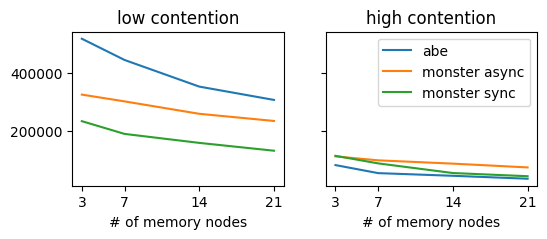

In [171]:
fig, axs = plt.subplots(1,2,figsize=(6, 2), sharey="all")

mnodes = [3,7,14,21]

ax = axs[0]
abe_tput= [517672, 444434, 352620, 306652]
monsterasync_tput = [325026, 301641, 258823, 234177]
monstersync_tput = [233451, 189537, 158530, 131540]

ax.set_title("low contention")
ax.plot(mnodes, abe_tput, label="abe")
ax.plot(mnodes, monsterasync_tput, label="monster async")
ax.plot(mnodes, monstersync_tput, label="monster sync")
ax.set_xticks(mnodes)
ax.set_xlabel("# of memory nodes")

ax = axs[1]
abe_tput= [82000, 54285, 45098, 35000]
monsterasync_tput = [112000, 98375, 87000, 74000 ]
monstersync_tput = [ 113875, 87875, 54625, 43625 ]

ax.set_title("high contention")
ax.plot(mnodes, abe_tput, label="abe")
ax.plot(mnodes, monsterasync_tput, label="monster async")
ax.plot(mnodes, monstersync_tput, label="monster sync")

ax.set_xlabel("# of memory nodes")
ax.set_xticks(mnodes)
ax.legend()